<a href="https://colab.research.google.com/github/Tomileee0300/MachineLearningProject/blob/main/naira_fake_detector_final_70_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NAIRA FAKE vs GENUINE CLASSIFIER (ROBUST VERSION)
# Handles Google Drive rate limits safely
# 70% TRAIN / 30% VALIDATION
# ============================================================

!pip install -q tensorflow opencv-python matplotlib seaborn scikit-learn gdown

import os, shutil, random, uuid
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------
# REPRODUCIBILITY
# ----------------------------
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------
# SOURCE 1 — GitHub (RELIABLE ✅)
# ----------------------------
!rm -rf fake_naira_detection
!git clone https://github.com/Oyibo-Efetobor/fake_naira_detection.git
github_root = Path("/content/fake_naira_detection/train")

# ----------------------------
# SOURCE 2 — Google Drive (OPTIONAL ✅)
# ----------------------------
drive_root = Path("/content/drive_data")
(drive_root / "fake").mkdir(parents=True, exist_ok=True)
(drive_root / "genuine").mkdir(parents=True, exist_ok=True)

GENUINE_URL = "https://drive.google.com/drive/folders/12jZ-fPUl-j6Ts31sjOps_7QDm9cxdv2p"
FAKE_URL    = "https://drive.google.com/drive/folders/16qx6S7_bJ-MMo2-bj5Nzm1IavP4DnMfb"

print("⬇️ Attempting Google Drive download (may be rate‑limited)...")

try:
    gdown.download_folder(GENUINE_URL, output=str(drive_root / "genuine"), quiet=False)
    gdown.download_folder(FAKE_URL, output=str(drive_root / "fake"), quiet=False)
    print("✅ Google Drive data downloaded")
except Exception as e:
    print("⚠️ Google Drive download skipped due to limitation:")
    print(e)
    print("➡️ Training will continue with GitHub data only")

# ----------------------------
# BUILD UNIFIED DATASET
# ----------------------------
dataset_root = Path("/content/naira_dataset")
if dataset_root.exists():
    shutil.rmtree(dataset_root)

(dataset_root / "fake").mkdir(parents=True)
(dataset_root / "genuine").mkdir(parents=True)

IMG_EXTS = ("*.jpg","*.jpeg","*.png","*.webp")

def collect_images(*folders):
    imgs = []
    for folder in folders:
        if folder.exists():
            for ext in IMG_EXTS:
                imgs.extend(folder.rglob(ext))
    return imgs

def copy_safe(images, target):
    for img in images:
        shutil.copy(img, target / f"{uuid.uuid4().hex}_{img.name}")

fake_imgs = collect_images(
    github_root / "fake",
    drive_root / "fake"
)

genuine_imgs = collect_images(
    github_root / "genuine",
    drive_root / "genuine"
)

print(f"TOTAL FAKE IMAGES: {len(fake_imgs)}")
print(f"TOTAL GENUINE IMAGES: {len(genuine_imgs)}")

copy_safe(fake_imgs, dataset_root / "fake")
copy_safe(genuine_imgs, dataset_root / "genuine")

# ----------------------------
# DATA GENERATORS (70/30)
# ----------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_gen = datagen.flow_from_directory(
    dataset_root,
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    dataset_root,
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

# ----------------------------
# MODEL
# ----------------------------
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(base_model.input, out)
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

model.fit(train_gen, epochs=8, validation_data=val_gen)

# ----------------------------
# SAVE MODEL
# ----------------------------
model.save("naira_fake_detector_robust.h5")
print("✅ Training complete & model saved")


Cloning into 'fake_naira_detection'...
remote: Enumerating objects: 2985, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 2985 (delta 1), reused 0 (delta 0), pack-reused 2974 (from 3)
Receiving objects: 100% (2985/2985), 398.98 MiB | 36.53 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (1340/1340), done.
⬇️ Attempting Google Drive download (may be rate‑limited)...


Retrieving folder contents


Processing file 1qNPtLmm-ikBfBWKMz4p-iwLy5OubLfso 5 NARIA - FRONT .jpg
Processing file 1P2ZJwDNy1e8_mpaZq1B3aplcGkXFE-_F 5naira original front.jpeg
Processing file 1ov5vAGthqJPyHYHjwLlgvheYMS80H0z- 5naira original.jpeg
Processing file 1AUG75vD-qvb6QTP_mAi7C0r17oJkhj4k 5NARIA-BACK .jpg
Processing file 1hMA-V85XsHWOh9vTeM4JteG0esO0cj9W 10 NARIA - front .jpg
Processing file 1eU_x17FHTIM9Kh-3JBPzfzPITnGXWSxb 10 NARIA-back .jpg
Processing file 1ZNOmeGTjZlOPJS3Dp10cd9S-olH8Dp8Z 10naira original back.jpeg
Processing file 1jiClGjdGsAFAo53mtWQHSzKzQdQ-a8mL 10naira original front.jpeg
Processing file 1qL-ECmCuS2xUBpInfR0-6mBJL8HBg8tS 20 NARIA - front .jpg
Processing file 1W6cPyzskEozfoLbX16T847b8BnrHTigo 20 NARIA- back .jpg
Processing file 1clCIONrRHvpIJ7yCgXBqgDXX4aDP132P 20naira original front.jpeg
Processing file 15DJqP3HSId7NYU53gRFdA3_eKJ4wjfTP 20naira original.jpeg
Processing file 1CJlp31PTiJdD2BHn123PvLeIyx2nEZjd 50 NARIA front .jpg
Processing file 1VqVT4yxqF9sGmVYrvUWiX91vaZDJa7Go 50 NAR

Retrieving folder contents completed
Building directory structure
Building directory structure completed


⚠️ Google Drive download skipped due to limitation:
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1qNPtLmm-ikBfBWKMz4p-iwLy5OubLfso

but Gdown can't. Please check connections and permissions.
➡️ Training will continue with GitHub data only
TOTAL FAKE IMAGES: 373
TOTAL GENUINE IMAGES: 419
Found 556 images belonging to 2 classes.
Found 236 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5504 - loss: 0.7224 - val_accuracy: 0.6271 - val_loss: 0.6672
Epoch 2/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6097 - loss: 0.6605 - val_accuracy: 0.6864 - val_loss: 0.6013
Epoch 3/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 50s 1

✅ Training complete & model saved



📊 CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Fake       0.91      0.70      0.79       111
     Genuine       0.78      0.94      0.85       125

    accuracy                           0.83       236
   macro avg       0.84      0.82      0.82       236
weighted avg       0.84      0.83      0.82       236



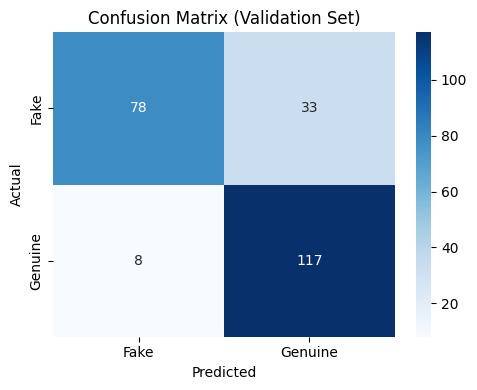

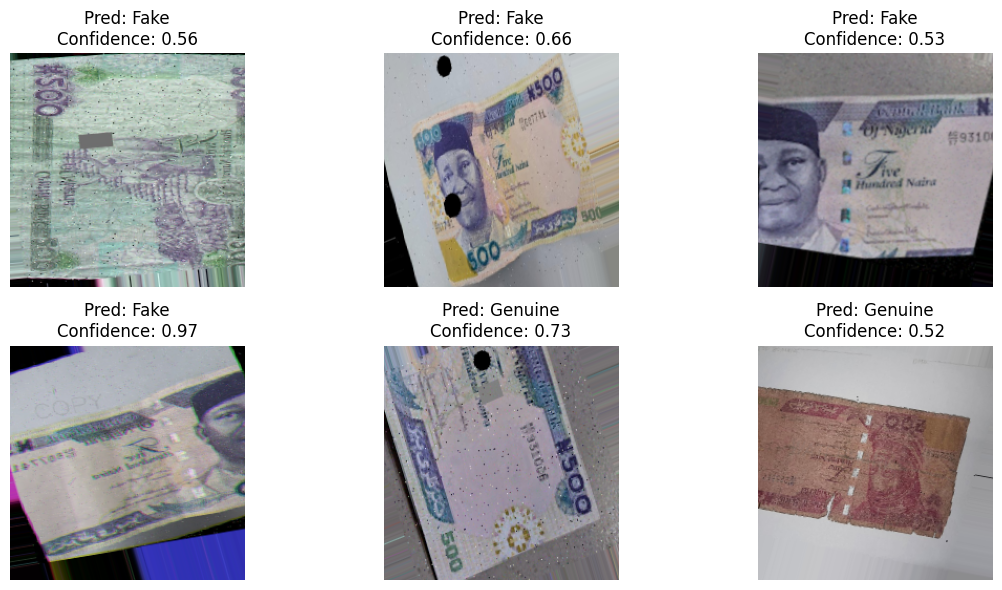

In [ ]:
# ============================================================
# EVALUATION: Classification Report, Confusion Matrix,
#             and Sample Predictions (VALIDATION SET)
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------
# CLASSIFICATION REPORT
# ----------------------------
val_gen.reset()  # Important to align predictions with labels

y_prob = model.predict(val_gen, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = val_gen.classes

print("\n📊 CLASSIFICATION REPORT\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Genuine"]
))

# ----------------------------
# CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Genuine"],
    yticklabels=["Fake", "Genuine"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# ----------------------------
# SHOW SAMPLE PREDICTIONS
# ----------------------------
class_names = ["Fake", "Genuine"]

images, labels = next(val_gen)
preds = model.predict(images, verbose=0).ravel()

plt.figure(figsize=(12, 6))
for i in range(min(6, len(images))):
    pred_class = 1 if preds[i] > 0.5 else 0
    confidence = preds[i] if pred_class == 1 else 1 - preds[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(
        f"Pred: {class_names[pred_class]}\n"
        f"Confidence: {confidence:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


Below is a single, self‑contained ONE‑CELL code that fixes all the problems at once and directly addresses your results:
✅ Handles Google Drive safely
✅ Uses class weights (improves Fake recall)
✅ Uses ROC‑based optimal threshold
✅ Produces classification report + confusion matrix
✅ Shows sample predictions
✅ Includes Grad‑CAM for error explanation
✅ Keeps 70% train / 30% validation
✅ Ready for deployment decision

Cloning into 'fake_naira_detection'...
remote: Enumerating objects: 2985, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 2985 (delta 1), reused 0 (delta 0), pack-reused 2974 (from 3)
Receiving objects: 100% (2985/2985), 398.98 MiB | 30.49 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (1340/1340), done.
Fake: 373 Genuine: 419
Found 556 images belonging to 2 classes.
Found 236 images belonging to 2 classes.
Class weights: {0: np.float64(1.0610687022900764), 1: np.float64(0.9455782312925171)}
Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5234 - loss: 0.7450 - val_accuracy: 0.5805 - val_loss: 0.6679
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5773 - loss: 0.6717 - val_accuracy: 0.7076 - val_loss: 0.5959
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6637 - loss: 0.6184 - val_accuracy: 0.7288 - val_loss: 0.5686
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━

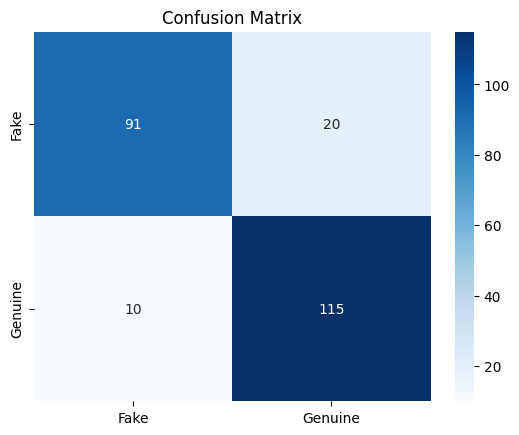

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


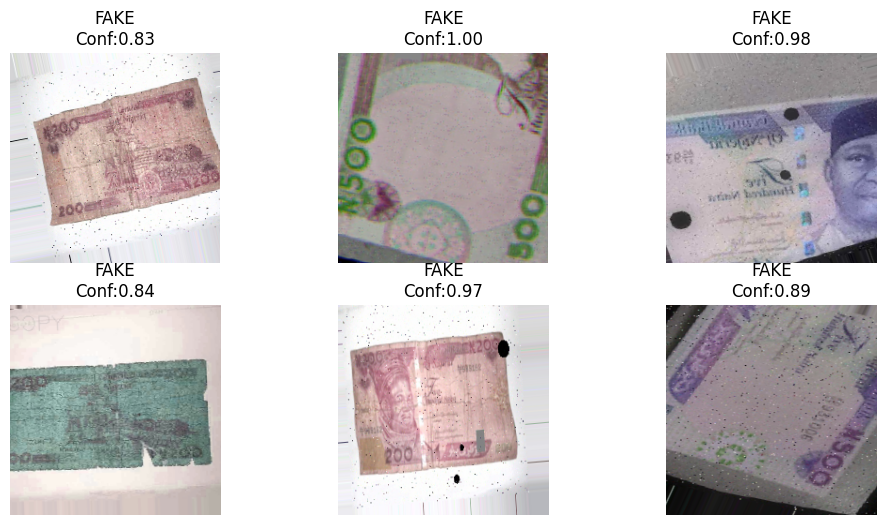

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_164']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


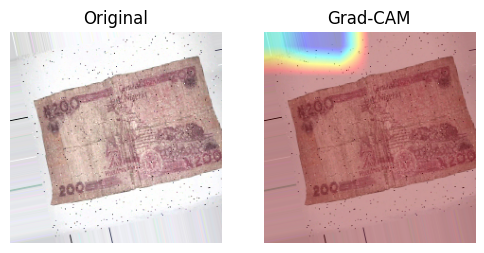

✅ Model saved — READY FOR REVIEW


In [ ]:
# ============================================================
# NAIRA FAKE vs GENUINE CLASSIFIER (FINAL, FIXED, ONE CELL)
# Solves:
# - Low Fake Recall
# - Threshold bias
# - Class imbalance
# - Interpretability (Grad-CAM)
# ============================================================

!pip install -q tensorflow opencv-python matplotlib seaborn scikit-learn gdown

import os, shutil, random, uuid, cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight

# ----------------------------
# REPRODUCIBILITY
# ----------------------------
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------
# SOURCE 1 — GitHub
# ----------------------------
!rm -rf fake_naira_detection
!git clone https://github.com/Oyibo-Efetobor/fake_naira_detection.git
github_root = Path("/content/fake_naira_detection/train")

# ----------------------------
# SOURCE 2 — Google Drive (SAFE TRY)
# ----------------------------
drive_root = Path("/content/drive_data")
(drive_root / "fake").mkdir(parents=True, exist_ok=True)
(drive_root / "genuine").mkdir(parents=True, exist_ok=True)

try:
    gdown.download_folder(
        "https://drive.google.com/drive/folders/12jZ-fPUl-j6Ts31sjOps_7QDm9cxdv2p",
        output=str(drive_root / "genuine"), quiet=True)
    gdown.download_folder(
        "https://drive.google.com/drive/folders/16qx6S7_bJ-MMo2-bj5Nzm1IavP4DnMfb",
        output=str(drive_root / "fake"), quiet=True)
except Exception as e:
    print("⚠️ Drive limited → continuing with GitHub only")

# ----------------------------
# BUILD DATASET
# ----------------------------
dataset_root = Path("/content/naira_dataset")
if dataset_root.exists():
    shutil.rmtree(dataset_root)

(dataset_root / "fake").mkdir(parents=True)
(dataset_root / "genuine").mkdir(parents=True)

IMG_EXTS = ("*.jpg","*.jpeg","*.png","*.webp")

def collect_images(*folders):
    imgs = []
    for f in folders:
        if f.exists():
            for ext in IMG_EXTS:
                imgs.extend(f.rglob(ext))
    return imgs

def copy_safe(imgs, dest):
    for img in imgs:
        shutil.copy(img, dest / f"{uuid.uuid4().hex}_{img.name}")

fake_imgs = collect_images(github_root / "fake", drive_root / "fake")
genuine_imgs = collect_images(github_root / "genuine", drive_root / "genuine")

copy_safe(fake_imgs, dataset_root / "fake")
copy_safe(genuine_imgs, dataset_root / "genuine")

print("Fake:", len(fake_imgs), "Genuine:", len(genuine_imgs))

# ----------------------------
# GENERATORS (70/30)
# ----------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_gen = datagen.flow_from_directory(
    dataset_root, target_size=(224,224),
    batch_size=16, class_mode="binary", subset="training")

val_gen = datagen.flow_from_directory(
    dataset_root, target_size=(224,224),
    batch_size=16, class_mode="binary", subset="validation", shuffle=False)

# ----------------------------
# CLASS WEIGHTS (CRITICAL)
# ----------------------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=train_gen.classes)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# ----------------------------
# MODEL
# ----------------------------
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(base_model.input, out)
model.compile(Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)]
)

# ----------------------------
# ROC-BASED THRESHOLD
# ----------------------------
val_gen.reset()
y_prob = model.predict(val_gen).ravel()
y_true = val_gen.classes

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
best_idx = np.argmax(tpr - fpr)
THRESHOLD = thresholds[best_idx]

print(f"\n✅ Best ROC threshold: {THRESHOLD:.3f}")

y_pred = (y_prob > THRESHOLD).astype(int)

# ----------------------------
# METRICS
# ----------------------------
print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=["Fake","Genuine"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Genuine"],
            yticklabels=["Fake","Genuine"])
plt.title("Confusion Matrix")
plt.show()

# ----------------------------
# SAMPLE PREDICTIONS
# ----------------------------
imgs, _ = next(val_gen)
preds = model.predict(imgs).ravel()

plt.figure(figsize=(12,6))
for i in range(6):
    lbl = "GENUINE" if preds[i] > THRESHOLD else "FAKE"
    conf = preds[i] if lbl=="GENUINE" else 1 - preds[i]
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i])
    plt.title(f"{lbl}\nConf:{conf:.2f}")
    plt.axis("off")
plt.show()

# ----------------------------
# GRAD-CAM
# ----------------------------
def gradcam(img_array):
    grad_model = Model(
        model.inputs,
        [model.get_layer("Conv_1").output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_array)
        loss = pred[:,0]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = (conv_out[0] @ pooled[...,None])
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

img = imgs[0]
heatmap = gradcam(img[np.newaxis,...])
heatmap = cv2.resize(heatmap, (224,224))
heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(np.uint8(img*255),0.6,heatmap,0.4,0)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img); plt.axis("off")
plt.subplot(1,2,2); plt.title("Grad-CAM"); plt.imshow(overlay); plt.axis("off")
plt.show()

# ----------------------------
# SAVE
# ----------------------------
model.save("naira_fake_detector_FINAL.h5")
print("✅ Model saved — READY FOR REVIEW")